# Build cavities from parameters

In this tutorial we build the parametric geometries that come from cavsim2d: an
elliptical cavity (one TESLA cell, then the 9-cell cavity), a flat-top cavity, a
pillbox, a spline cavity, an RF gun and four beam-line elements. We give their
parameters directly and as config dictionaries, and check the volume of a meshed
pillbox against its exact value.

**Prerequisites:** [Your first simulation](../basics/first_simulation.ipynb). No files
are needed.

Each geometry is the 2D meridian contour of the cavsim2d model of the same name, revolved
about the z axis. The constructors take the cavsim2d arguments, with lengths in
millimetres by default. The mesh size `maxh` is in metres, as everywhere else.

In [1]:
from cavsim3d.core.em_project import EMProject
from cavsim3d.geometry import (EllipticalCavity, EllipticalCavityFlatTop, Pillbox,
                               SplineCavity, RFGun, Beampipe, BLA, Bellows, Taper)
import matplotlib.pyplot as plt
import numpy as np
from ngsolve import Integrate, CoefficientFunction

## 1. Build an elliptical cavity

### 1.1 Describe a cell with seven numbers

A half-cell of an elliptical cavity is `[A, B, a, b, Ri, L, Req]`: the equator ellipse
semi-axes `A`, `B`, the iris ellipse semi-axes `a`, `b`, the iris radius `Ri`, the
half-cell length `L` and the equator radius `Req`. We build one TESLA cell with a beam
pipe at each end.

In [2]:
tesla_mid = [42, 42, 12, 19, 35, 57.7, 103.353]      # A, B, a, b, Ri, L, Req [mm]

cell = EllipticalCavity(n_cells=1, mid_cell=tesla_mid, beampipe="both")
print("ports:", cell.ports)
print("mesh: ", cell.mesh)

ports: ['port1', 'port2']
mesh:  None


The cavity has two ports, one at each beam-pipe end. It has no mesh yet: building a
geometry only creates the solid, and the mesh is made later by `generate_mesh`
(section 4).

### 1.2 Look at the geometry

`plot_profile` draws the meridian contour that is revolved about the z axis, with the
ports in red. The commented line opens the interactive 3D view of the solid.

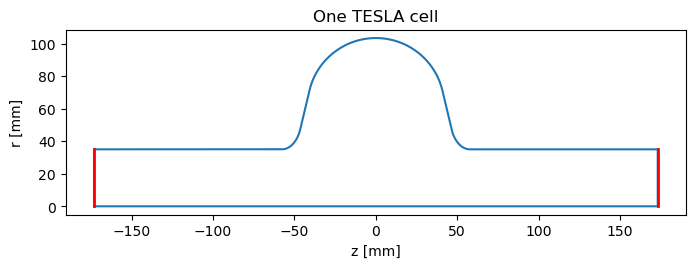

In [3]:
cell.plot_profile()
plt.title("One TESLA cell")
plt.show()
# cell.show("geometry")          # interactive 3D view

The beam pipes are `2 * L` long by default; `beampipe_length=` sets another length.

### 1.3 Build the 9-cell cavity with its end cells

The TESLA cavity has 7 identical mid cells and two different end cells. Each end cell
is given in the same seven-number form.

half-cells: (18, 7)
wall angles [deg]: {'m': 103.28, 'el': 106.03, 'er': 107.31}


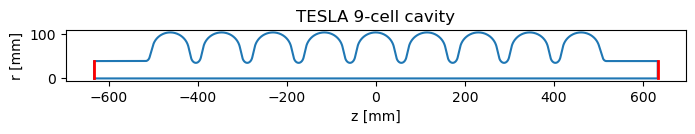

In [4]:
tesla_end_left = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
tesla_end_right = [42, 42, 9, 12.8, 39, 56.815, 103.353]

tesla = EllipticalCavity(n_cells=9, mid_cell=tesla_mid, end_cell_left=tesla_end_left,
                         end_cell_right=tesla_end_right, beampipe="both")
print("half-cells:", tesla.half_cells().shape)
print("wall angles [deg]:", {k: round(v, 2) for k, v in tesla.wall_angles().items()})

tesla.plot_profile()
plt.title("TESLA 9-cell cavity")
plt.show()
# tesla.show("geometry")

The 18 half-cells run from the left end cell to the right end cell. The wall angle of
each cell type is derived from its seven numbers.

### 1.4 Chain cavities into a module

`chain=` repeats the cavity end-to-end into one solid; `spacing=` sets the drift between
neighbouring cavities, iris to iris.

ports: ['port1', 'port2']


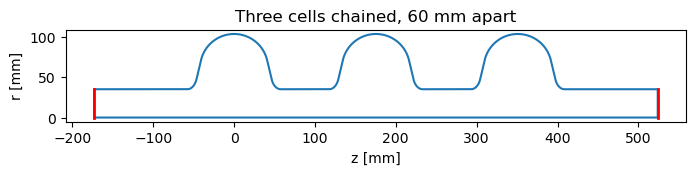

In [5]:
module = EllipticalCavity(n_cells=1, mid_cell=tesla_mid, beampipe="both",
                          chain=3, spacing=60)
print("ports:", module.ports)
module.plot_profile()
plt.title("Three cells chained, 60 mm apart")
plt.show()
# module.show("geometry")

The module keeps only the two outer ports: the inner beam pipes became the drifts.

## 2. Pass the parameters as a config dictionary

### 2.1 Build from one dictionary

Every geometry takes its arguments as one dictionary, `config=`. The keys are the
argument names.

In [6]:
tesla_cfg = {
    "n_cells": 9,
    "mid_cell": tesla_mid,
    "end_cell_left": tesla_end_left,
    "end_cell_right": tesla_end_right,
    "beampipe": "both",
}
tesla_from_cfg = EllipticalCavity(config=tesla_cfg)
print(np.allclose(tesla_from_cfg.profile().contour_points(),
                  tesla.profile().contour_points()))

True


The geometry built from the dictionary is the same as the one built in 1.3.

### 2.2 Change one parameter

An argument given directly takes precedence over the dictionary, so one dictionary can
describe a family of cavities.

3 200


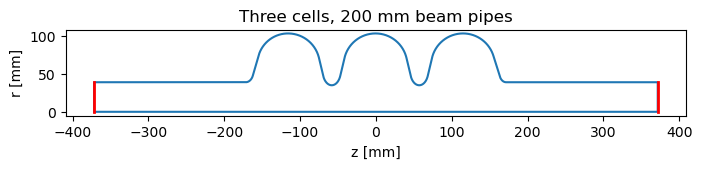

In [7]:
three_cell = EllipticalCavity(config=tesla_cfg, n_cells=3, beampipe_length=200)
print(three_cell.n_cells, three_cell.beampipe_length)

three_cell.plot_profile()
plt.title("Three cells, 200 mm beam pipes")
plt.show()
# three_cell.show("geometry")

### 2.3 Give the lengths in another unit

Lengths are in millimetres unless `unit=` says otherwise. The same cell in metres:

In [8]:
cell_in_m = EllipticalCavity(config={"n_cells": 1,
                                     "mid_cell": np.array(tesla_mid) / 1000,
                                     "beampipe": "both",
                                     "unit": "m"})
print(np.allclose(cell_in_m.profile().contour_points(),
                  cell.profile().contour_points()))

True


Both describe the same solid. The RF gun is the one exception to the default: as in
cavsim2d, its lengths are in metres (section 3.4).

## 3. The other geometries

Each geometry below is built from a config dictionary and shown after it is built.

### 3.1 Flat-top elliptical cavity

The flat-top cavity adds an eighth number, `l`: a straight section at the equator.

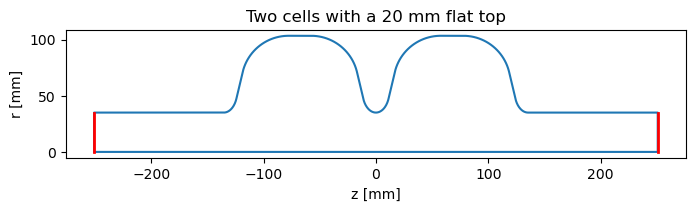

In [9]:
flattop_cfg = {"n_cells": 2, "mid_cell": tesla_mid + [20], "beampipe": "both"}
flattop = EllipticalCavityFlatTop(config=flattop_cfg)
flattop.plot_profile()
plt.title("Two cells with a 20 mm flat top")
plt.show()
# flattop.show("geometry")

### 3.2 Pillbox

`dims` is `[L, Req, Ri, S, L_bp]`: cell length, cavity radius, aperture radius, the drift
between cells and the beam-pipe length.

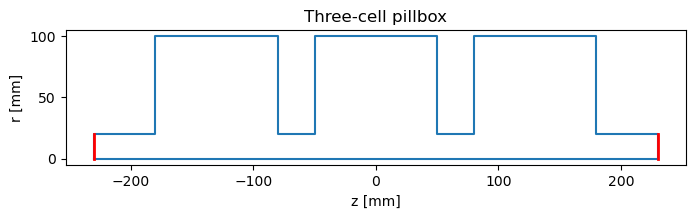

In [10]:
pillbox_cfg = {"n_cells": 3, "dims": [100, 100, 20, 30, 50], "beampipe": "both"}
pillbox = Pillbox(config=pillbox_cfg)
pillbox.plot_profile()
plt.title("Three-cell pillbox")
plt.show()
# pillbox.show("geometry")

### 3.3 Spline cavity

The wall is a spline defined by control points `[z, r]`, one set per cell. The curve
starts at the first point and ends at the last; the points between pull it without
lying on it. With `kind="Bezier"` each cell is one Bezier curve; `kind="bspline"` fits
one B-spline through all the points.

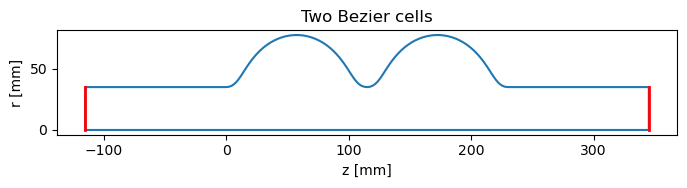

In [11]:
spline_points = {"p0": [0, 35], "p1": [25, 35], "p2": [5, 103],
                 "p3": [110, 103], "p4": [90, 35], "p5": [115, 35]}
spline_cfg = {"shape": {"geometry": spline_points, "n_cells": 2, "beampipe": "both"},
              "kind": "Bezier"}
spline = SplineCavity(config=spline_cfg)
spline.plot_profile()
plt.title("Two Bezier cells")
plt.show()
# spline.show("geometry")

The equator stays below 103 mm, the radius of the middle points: they pull the curve
but do not lie on it. A multi-cell B-spline built by repeating one cell's points has a
point where the curve stops (its tangent vanishes) at every iris, which cannot be
meshed. The code refuses it and says so; use `kind="Bezier"` for several cells.

### 3.4 RF gun

The gun's wall is a chain of arcs and straight segments, from the cathode plane to the
exit. Its lengths are in metres and its angles (`T2`, `T9`, `T10`) in radians, as in
cavsim2d.

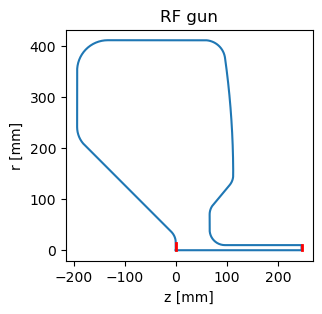

In [12]:
gun_cfg = {"shape": {"geometry": {
    "y1": 1.5e-2, "R2": 3e-2, "T2": 0.7853981633974483, "L3": 24e-2,
    "R4": 5e-2, "L5": 11e-2, "R6": 6e-2, "L7": 19e-2, "R8": 4e-2,
    "T9": 0.13962634015954636, "R10": 3e-2, "T10": 0.6981317007977318,
    "L11": 5e-2, "R12": 3e-2, "L13": 3e-2, "R14": 3e-2, "x": 1e-2}}}
gun = RFGun(config=gun_cfg)
gun.plot_profile()
plt.title("RF gun")
plt.show()
# gun.show("geometry")

The ports are the cathode plane (left) and the exit aperture (right).
`beampipe="left"` adds a beam pipe on the cathode side.

### 3.5 Beam pipe

`ends` makes each end an open port (`"pmc"`, the default) or a metal plate (`"pec"`).

ports: ['port1']


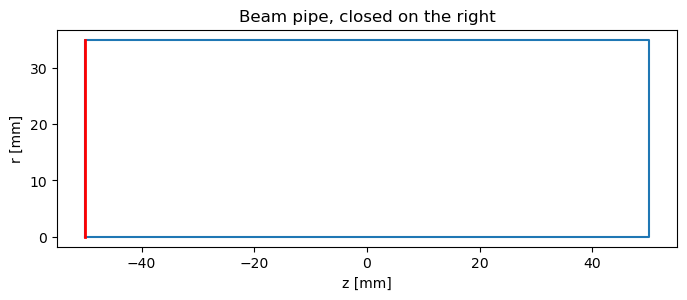

In [13]:
pipe = Beampipe(config={"R": 35, "L": 100, "ends": ("pmc", "pec")})
print("ports:", pipe.ports)
pipe.plot_profile()
plt.title("Beam pipe, closed on the right")
plt.show()
# pipe.show("geometry")

With the right end closed, the pipe has one port.

### 3.6 Beam-line absorber

A beam pipe whose wall steps out to hold a lossy ring. The ring (shaded) is a second
material, `"absorber"`, with the permittivity and loss tangent given here.

{'eps_r': 10.0, 'mu_r': 1.0, 'sigma': 0.0, 'tan_delta': 0.3}


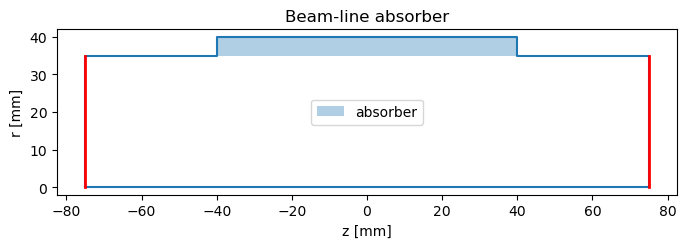

In [14]:
bla_cfg = {"R": 35, "L": 150, "absorber_length": 80, "absorber_thickness": 5,
           "eps_r": 10, "tan_delta": 0.3}
bla = BLA(config=bla_cfg)
print(bla.get_material("absorber"))
bla.plot_profile()
plt.title("Beam-line absorber")
plt.show()
# bla.show("geometry")

### 3.7 Bellows

A corrugated section of `N_conv` convolutions, each corner rounded by its own radius.

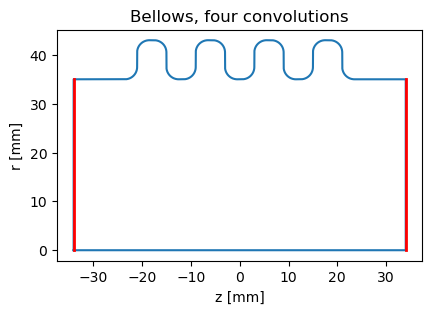

In [15]:
bellows_cfg = {"Ri": 35, "A": 8, "L_p": 12, "N_conv": 4, "R_root": 2.5, "R_crest": 2.5,
               "L_bp": 10}
bellows = Bellows(config=bellows_cfg)
bellows.plot_profile()
plt.title("Bellows, four convolutions")
plt.show()
# bellows.show("geometry")

Small corner radii make a fine mesh: netgen refines the mesh to the curvature of the
wall, not only to `maxh`.

### 3.8 Taper

A cone from one bore to another, with straight runs at the ends and rounded corners.

half-angle: 29.36 deg


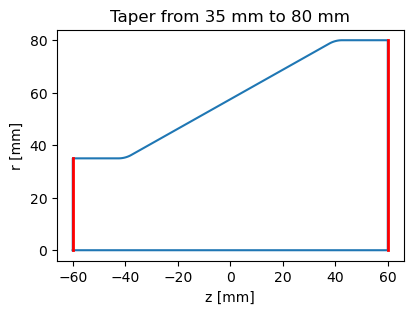

In [16]:
taper_cfg = {"R_left": 35, "R_right": 80, "L": 120, "straight_left": 20,
             "straight_right": 20, "R_fillet": 10}
taper = Taper(config=taper_cfg)
print(f"half-angle: {taper.half_angle:.2f} deg")
taper.plot_profile()
plt.title("Taper from 35 mm to 80 mm")
plt.show()
# taper.show("geometry")

## 4. Use a geometry in a project

### 4.1 Add a pillbox as a part

`create_primitive` adds any of these geometries to a project; `config=` passes the same
dictionary.

In [17]:
proj = EMProject(name="pillbox_part", base_dir="./simulations", overwrite=True)
one_cell_cfg = {"n_cells": 1, "dims": [100, 100, 20, 0, 50], "beampipe": "both"}
part = proj.create_primitive("pillbox", name="pillbox", config=one_cell_cfg)
print("parts:", list(proj.parts), "| mesh:", part.mesh)

✅ Creating new project 'pillbox_part' at simulations\pillbox_part


parts: ['pillbox'] | mesh: None


The part has no mesh yet.

### 4.2 Mesh it

`generate_mesh` makes the mesh; `maxh` is in metres. (If a solve starts before any
mesh is made, the part is meshed with the `maxh` given to its constructor.)

In [18]:
proj.generate_mesh(maxh=0.02)
print(f"{proj.mesh.ne} elements, boundaries {sorted(set(proj.mesh.GetBoundaries()))}")
# proj.geometry.show("mesh")      # interactive 3D view of the mesh

2657 elements, boundaries ['default', 'port1', 'port2']


The two ports and the wall (`default`) are named on the mesh, ready for a solve.

### 4.3 Check the volume against the exact value

One cell of radius 100 mm and length 100 mm, and two beam pipes of radius 20 mm and
length 50 mm, hold `pi * (0.1**2 * 0.1 + 2 * 0.02**2 * 0.05)` cubic metres.

In [19]:
exact = np.pi * (0.1**2 * 0.1 + 2 * 0.02**2 * 0.05)
meshed = Integrate(CoefficientFunction(1), proj.mesh)
print(f"exact  {exact:.6e} m^3")
print(f"meshed {meshed:.6e} m^3  (relative difference {abs(meshed - exact) / exact:.1e})")

exact  3.267256e-03 m^3
meshed 3.267271e-03 m^3  (relative difference 4.4e-06)


## What we did

We built elliptical cavities from their seven cell parameters, chained cavities into a
module, passed parameters as config dictionaries and in another unit, built every other
geometry from cavsim2d, and meshed a pillbox whose volume matches the exact value.

**Next:** [Import a CAD model](cad_import.ipynb).

**Background:** [Geometry reference](../../api/geometry.md#bodies-of-revolution) lists
every geometry and argument.